<a href="https://colab.research.google.com/github/nataliakaye5-ai/PyTorch/blob/main/Efficient%20Froniter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Annualised Asset Returns ---
Global_Equity_A       0.129269
UK_Equity_B           0.082639
Fixed_Income_C        0.137448
Emerging_Markets_D    0.142458
Alternative_E         0.208771
dtype: float64

--- Optimisation Results ---
Global_Equity_A Optimal Allocation: 16.87%
UK_Equity_B Optimal Allocation: 10.42%
Fixed_Income_C Optimal Allocation: 18.23%
Emerging_Markets_D Optimal Allocation: 22.78%
Alternative_E Optimal Allocation: 31.70%

Expected Portfolio Return: 15.41%
Optimised Portfolio Volatility: 7.45%
Maximum Sharpe Ratio: 1.80


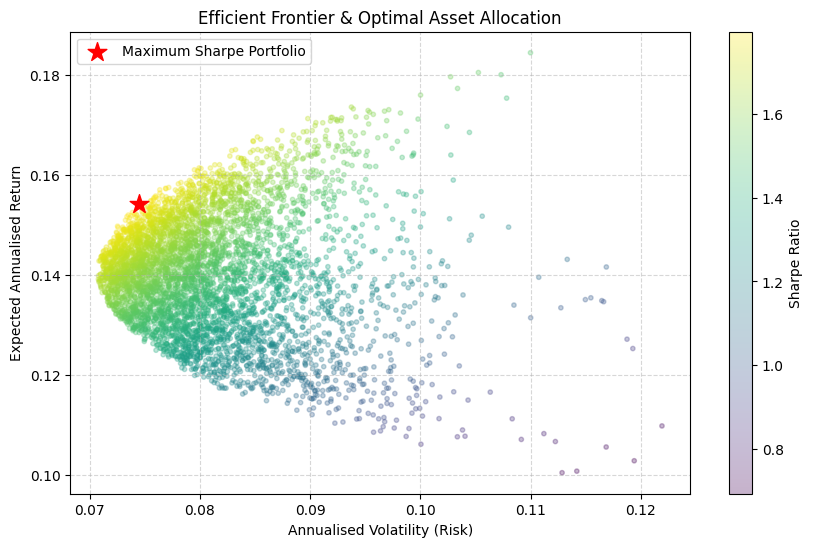

In [1]:
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt

# 1. Generate Synthetic Asset Data (Simulating High-Dimensional Financial Returns)
np.random.seed(42)
num_assets = 5
num_trading_days = 1000

# Generate random daily returns for 5 distinct assets
random_returns = np.random.normal(0.0005, 0.01, (num_trading_days, num_assets))
asset_names = ['Global_Equity_A', 'UK_Equity_B', 'Fixed_Income_C', 'Emerging_Markets_D', 'Alternative_E']
df_returns = pd.DataFrame(random_returns, columns=asset_names)

# Calculate annualised mean returns and covariance matrix (assuming 252 trading days)
annual_returns = df_returns.mean() * 252
cov_matrix = df_returns.cov() * 252

print("--- Annualised Asset Returns ---")
print(annual_returns)

# 2. Define Portfolio Performance Metrics
def portfolio_statistics(weights, annual_returns, cov_matrix, risk_free_rate=0.02):
    """
    Calculates expected portfolio return, annualised volatility, and Sharpe ratio.
    """
    p_return = np.sum(annual_returns * weights)
    p_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    p_sharpe = (p_return - risk_free_rate) / p_volatility
    return np.array([p_return, p_volatility, p_sharpe])

# 3. Define the Objective Function for Optimisation (Negative Sharpe Ratio)
def min_func_sharpe(weights, annual_returns, cov_matrix, risk_free_rate=0.02):
    # We minimise the negative Sharpe ratio to maximise the actual Sharpe ratio
    return -portfolio_statistics(weights, annual_returns, cov_matrix, risk_free_rate)[2]

# 4. Set Optimisation Constraints and Boundaries
# Constraint: The sum of all asset weights must equal 1 (100% allocation)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds: Long-only portfolio (weights must sit strictly between 0 and 1)
bounds = tuple((0, 1) for asset in range(num_assets))

# Initial guess: Equal distribution across assets
initial_weights = num_assets * [1.0 / num_assets]

# 5. Execute Sequential Least Squares Programming (SLSQP) Optimisation
optimised_result = sco.minimize(
    min_func_sharpe,
    initial_weights,
    args=(annual_returns, cov_matrix),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

# Extract optimal weights
optimal_weights = optimised_result['x']
optimal_stats = portfolio_statistics(optimal_weights, annual_returns, cov_matrix)

print("\n--- Optimisation Results ---")
for asset, weight in zip(asset_names, optimal_weights):
    print(f"{asset} Optimal Allocation: {weight:.2%}")

print(f"\nExpected Portfolio Return: {optimal_stats[0]:.2%}")
print(f"Optimised Portfolio Volatility: {optimal_stats[1]:.2%}")
print(f"Maximum Sharpe Ratio: {optimal_stats[2]:.2f}")

# 6. Monte Carlo Simulation to Visualise the Efficient Frontier
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    w = np.random.random(num_assets)
    w /= np.sum(w) # Normalise weights to sum to 1
    stats = portfolio_statistics(w, annual_returns, cov_matrix)
    results[0, i] = stats[0] # Return
    results[1, i] = stats[1] # Volatility
    results[2, i] = stats[2] # Sharpe
    weights_record.append(w)

# Plotting the Efficient Frontier
plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_stats[1], optimal_stats[0], color='red', marker='*', s=200, label='Maximum Sharpe Portfolio')
plt.title('Efficient Frontier & Optimal Asset Allocation')
plt.xlabel('Annualised Volatility (Risk)')
plt.ylabel('Expected Annualised Return')
plt.legend(labelspacing=1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()